# Problème 2

## 🎯 Contexte
On cherche à déterminer un modèle afin de prédire si une personne sera acceptée ou non pour un prêt à la banque.

Voici les différentes variables:

➡️ `Reponse`: Est-ce que le prêt est accepté?  
➡️ `Cote`: La cote de crédit du demandant.  
➡️ `Salaire`: Le salaire annuel du demandant.  
➡️ `Genre`: Le genre du demandant.  

## 📁 Données utilisées
* 📗 DonneesTest2.xlsx
 --- 

### 👉 Importer des librairies
En premier, nous allons importer les librairies qui seront pertinentes pour cette section.

In [1]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Entraînement du modèle et mesures de performances
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Transformation et imputation des données
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

##### 📥 Importer les données

In [2]:
path = r"C:\Users\hatch\OneDrive - MONCCNB\Ecole\2ièmeAnnee\2-Hiver\STAT1040\Travaux\Test2"
fichier = r"\DonneesTest2.xlsx"

df = pd.read_excel(path+fichier, sheet_name="#2")
display(df.head())

,Reponse,Cote,Salaire,Genre
0,oui,730.0,62000,f
1,oui,780.0,25000,m
2,non,770.0,43000,f
3,oui,675.0,84000,m
4,oui,680.0,78000,m


##### 🔍 Observations et transformations préliminaires des données

In [3]:
# Vérification des types
print("~~~~~ Types de variables ~~~~~")
print(df.info())

# Vérification des données manquantes
print("\n~~~~~ Données manquantes % ~~~~~")
print(df.isna().sum().sort_values(ascending=False)/len(df))
df_clean = df.copy()
# Transformation de la variable « Reponse » en 0 et 1 
df_clean["Reponse"] = np.where(df_clean["Reponse"] == "oui", 1, 0)
display(df_clean.head())

~~~~~ Types de variables ~~~~~
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Reponse  100 non-null    object 
 1   Cote     100 non-null    float64
 2   Salaire  100 non-null    int64  
 3   Genre    100 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 3.3+ KB
None

~~~~~ Données manquantes % ~~~~~
Reponse    0.0
Cote       0.0
Salaire    0.0
Genre      0.0
dtype: float64


,Reponse,Cote,Salaire,Genre
0,1,730.0,62000,f
1,1,780.0,25000,m
2,0,770.0,43000,f
3,1,675.0,84000,m
4,1,680.0,78000,m


##### 📊 Analyse exploratoire des données

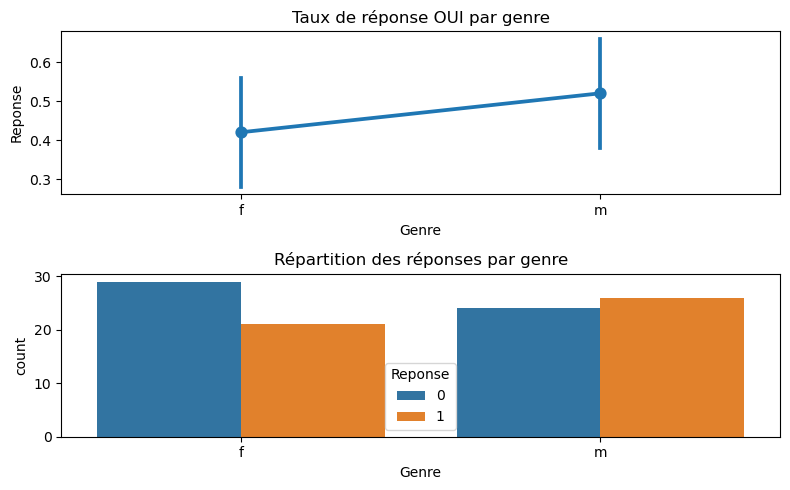

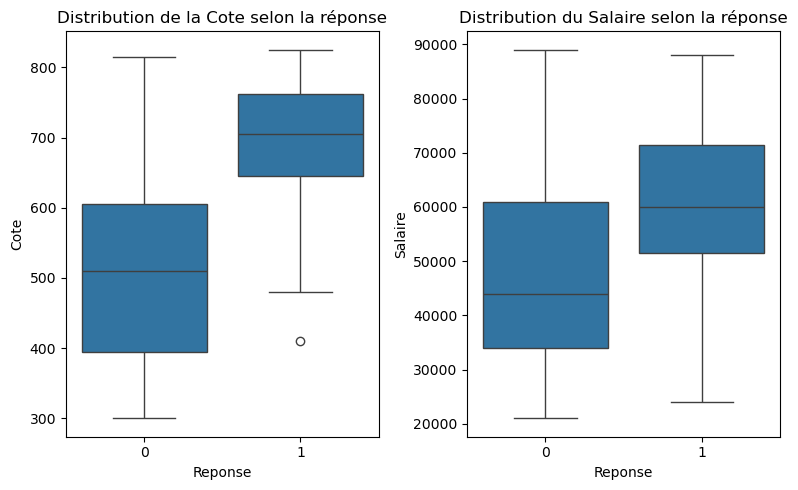

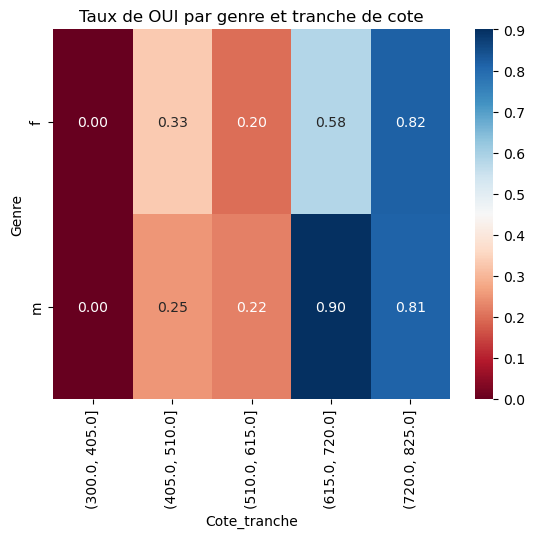

In [4]:


# ── 1. Variables catégorielles vs Reponse ──────────────────────────
fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(8,5))

sns.pointplot(y="Reponse", x="Genre", data=df_clean, ax=axes[0])
axes[0].set_title("Taux de réponse OUI par genre")

sns.countplot(x="Genre", hue="Reponse", data=df_clean, ax=axes[1])
axes[1].set_title("Répartition des réponses par genre")
plt.tight_layout()
plt.show()

# ── 2. Variables numériques vs Reponse ────────────────────────────
fig, axes = plt.subplots(ncols=2, figsize=(8, 5))

sns.boxplot(x="Reponse", y="Cote", data=df_clean, ax=axes[0])
axes[0].set_title("Distribution de la Cote selon la réponse")

sns.boxplot(x="Reponse", y="Salaire", data=df_clean, ax=axes[1])
axes[1].set_title("Distribution du Salaire selon la réponse")
plt.tight_layout()
plt.show()

# ── 3. Heatmap Cote par tranche × Genre ───────────────────────────
bins = np.linspace(df_clean["Cote"].min(), df_clean["Cote"].max(), num=6)
df_clean["Cote_tranche"] = pd.cut(df_clean["Cote"], bins)
pivot = df_clean.pivot_table(index="Genre", columns="Cote_tranche",
                       values="Reponse", observed=False)
sns.heatmap(pivot, cmap="RdBu", annot=True, fmt=".2f")
plt.title("Taux de OUI par genre et tranche de cote")
plt.show()



##### 💭 Réflexion
* Quelles variables semblent pertinentes et quelles variables ne semblent pas pertinentes pour votre modèle?
* - Cote et Salaire semblent être les variables les plus pertinentes pour prédire la réponse.
  - Genre semble peu pertinente car d'apres le pointplot, leurs intervalles de confiance se chevauchent.


##### 🧹 Transformation des données

In [5]:
X = df_clean[["Cote", "Salaire"]]
y = df_clean["Reponse"]

#Imputations et transformations
num_col= ["Cote", "Salaire"]
# cat_col=["Genre"]

numeric_transformer = Pipeline(
    [
        ("scaler", StandardScaler())
    ])



Preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_col)
    
])

##### 🧩 Train / Test 

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##### 🧬 Tuning du modèle de régression logistique

In [7]:
# Sélection du modèle et du pipeline de préparation

pipe_log = Pipeline([
    ("preprocess",Preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Sélection des hyperparametres à ajuster
param_log = {
    "model__C":[0.01,0.1,1,10,100,1000]
}

# l'ajustement se fait selon la meilleur mesure pour l'accuracy
grid_log = GridSearchCV(pipe_log, param_log, cv=5, scoring="accuracy")
grid_log.fit(X_train, y_train)

# Vérification des parametres optimaux
print(grid_log.best_params_, grid_log.best_score_)

{'model__C': 10} 0.7875


##### 🧬 Tuning du modèle KNN

In [8]:
# Sélection du modèle et du pipeline de préparation

pipe_knn = Pipeline([
    ("preprocess",Preprocessor),
    ("model", KNeighborsClassifier())
])

# Sélection des hyperparametres à ajuster
param_knn = {
    "model__n_neighbors":[3,5,7,9,11],
    "model__weights":["uniform","distance"]
}

# l'ajustement se fait selon la meilleur mesure pour l'accuracy
grid_knn = GridSearchCV(pipe_knn, param_knn, cv=5, scoring="accuracy")
grid_knn.fit(X_train, y_train)

# Vérification des parametres optimaux
print(grid_knn.best_params_, grid_knn.best_score_)

{'model__n_neighbors': 5, 'model__weights': 'uniform'} 0.825


##### 🔍 Comparaison des modèles

In [9]:
#### Évaluation des modèles
modeles = {"Régression_logistique":grid_log, "KNN":grid_knn}

for name,model in modeles.items():
    y_pred = model.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    print(f"Accuracy ({name}): {score:.4f}","\n")
    print(classification_report(y_test, y_pred))

Accuracy (Régression_logistique): 0.7000 

              precision    recall  f1-score   support

           0       0.64      0.78      0.70         9
           1       0.78      0.64      0.70        11

    accuracy                           0.70        20
   macro avg       0.71      0.71      0.70        20
weighted avg       0.71      0.70      0.70        20

Accuracy (KNN): 0.8500 

              precision    recall  f1-score   support

           0       0.80      0.89      0.84         9
           1       0.90      0.82      0.86        11

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.86      0.85      0.85        20



##### 💭 Réflexion

*  - Le modele KNN est plus adapté pour les predictions futurs car il est capable de predire les reponses à 85%, donc une performance supérieure de 15% par rapport au modèle de régression logique.

#### ✅ Prédiction finale
Un homme avec un salaire de 50 000 \$ et une code de crédit de 600 veut faire un prêt. Est-ce que sont prêt sera accepté?

Il faut vérifier l'information avec l'aide du modèle optimal qui a été entraîné sur l'ensemble des données.

In [10]:
# 5. ✅ Ré-entraîner le modèle FINAL sur TOUTES les données (X complet)
meilleurs_params = grid_knn.best_params_
modele_final = pipe_knn.set_params(**meilleurs_params)
modele_final.fit(X, y)  # <-- sur tout le dataset, plus seulement sur les données de tests

# Valeurs du nouveau client
valeurs = pd.DataFrame({
    "Cote":    [600],
    "Salaire": [50000]
})

# Prédiction directe — grid_knn contient déjà le Preprocessor
y_pred = modele_final.predict(valeurs)

# Affichage
print(f"Le prêt sera {'accepté' if y_pred[0] == 1 else 'refusé'} pour un homme avec un salaire de 50 000 $ et une cote de crédit de 600.")


Le prêt sera refusé pour un homme avec un salaire de 50 000 $ et une cote de crédit de 600.
